In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [44]:
import pandas as pd

df = pd.read_excel("Data/Bengaluru_Traffic_Cars.xlsx")
df.head()

,City,Year,Congestion %,10 km time,Rush hour speed,Rank,Congestion-relevant car trips/day,Estimated private car trips/day,Avg Trip km,Emission Factor,Vehicle Kilometres Travelled (VKT) (km/year),Unit,CO₂e (kg/year),CO₂e Tonnes
0,Bengaluru,2020,51.0,30 mins 10 sec,20.0,6,1000000,3400000,10.0,0.21,12410000000,km/year,2606100000,2606100
1,Bengaluru,2021,48.0,32 mins 15 sec,19.0,10,750000,3700000,8.0,0.21,10804000000,km/year,2268840000,2268840
2,Bengaluru,2022,68.0,29 mins 10 sec,18.0,2,1150000,4600000,9.2,0.21,15443200000,km/year,3243072000,3243072
3,Bengaluru,2023,63.0,28 mins 10 sec,18.0,6,1250000,5300000,9.8,0.21,18963700000,km/year,3982377000,3982377
4,Bengaluru,2024,72.7,30 mins 10 sec,15.0,3,1400000,6200000,10.5,0.21,23761500000,km/year,4989915000,4989915


In [45]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['city', 'year', 'congestion_%', '10_km_time', 'rush_hour_speed', 'rank',
       'congestion-relevant_car_trips/day', 'estimated_private_car_trips/day',
       'avg_trip_km', 'emission_factor',
       'vehicle_kilometres_travelled_(vkt)_(km/year)', 'unit',
       'co₂e_(kg/year)', 'co₂e_tonnes'],
      dtype='str')

In [46]:
df.head(10)

,city,year,congestion_%,10_km_time,rush_hour_speed,rank,congestion-relevant_car_trips/day,estimated_private_car_trips/day,avg_trip_km,emission_factor,vehicle_kilometres_travelled_(vkt)_(km/year),unit,co₂e_(kg/year),co₂e_tonnes
0,Bengaluru,2020,51.0,30 mins 10 sec,20.0,6,1000000,3400000,10.0,0.21,12410000000,km/year,2606100000,2606100
1,Bengaluru,2021,48.0,32 mins 15 sec,19.0,10,750000,3700000,8.0,0.21,10804000000,km/year,2268840000,2268840
2,Bengaluru,2022,68.0,29 mins 10 sec,18.0,2,1150000,4600000,9.2,0.21,15443200000,km/year,3243072000,3243072
3,Bengaluru,2023,63.0,28 mins 10 sec,18.0,6,1250000,5300000,9.8,0.21,18963700000,km/year,3982377000,3982377
4,Bengaluru,2024,72.7,30 mins 10 sec,15.0,3,1400000,6200000,10.5,0.21,23761500000,km/year,4989915000,4989915
5,Bengaluru,2025,74.4,36 mins 15 sec,13.9,2,1600000,6800000,11.0,0.21,27302000000,km/year,5733420000,5733420


In [47]:
df.columns = (
    df.columns
    .str.replace("%", "percent", regex=False)
    .str.replace("/", "_per_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

df.columns

Index(['city', 'year', 'congestion_percent', '10_km_time', 'rush_hour_speed',
       'rank', 'congestion-relevant_car_trips_per_day',
       'estimated_private_car_trips_per_day', 'avg_trip_km', 'emission_factor',
       'vehicle_kilometres_travelled_vkt_km_per_year', 'unit',
       'co₂e_kg_per_year', 'co₂e_tonnes'],
      dtype='str')

In [48]:
numeric_cols = [
    "year",
    "congestion_percent",
    "rush_hour_speed",
    "rank",
    "congestion-relevant_car_trips_per_day",
    "estimated_private_car_trips_per_day",
    "avg_trip_km",
    "emission_factor",
    "vehicle_kilometres_travelled_vkt_km_per_year"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   city                                          6 non-null      str    
 1   year                                          6 non-null      int64  
 2   congestion_percent                            6 non-null      float64
 3   10_km_time                                    6 non-null      str    
 4   rush_hour_speed                               6 non-null      float64
 5   rank                                          6 non-null      int64  
 6   congestion-relevant_car_trips_per_day         6 non-null      int64  
 7   estimated_private_car_trips_per_day           6 non-null      int64  
 8   avg_trip_km                                   6 non-null      float64
 9   emission_factor                               6 non-null      float64
 10  vehic

In [49]:
df.head()

,city,year,congestion_percent,10_km_time,rush_hour_speed,rank,congestion-relevant_car_trips_per_day,estimated_private_car_trips_per_day,avg_trip_km,emission_factor,vehicle_kilometres_travelled_vkt_km_per_year,unit,co₂e_kg_per_year,co₂e_tonnes
0,Bengaluru,2020,51.0,30 mins 10 sec,20.0,6,1000000,3400000,10.0,0.21,12410000000,km/year,2606100000,2606100
1,Bengaluru,2021,48.0,32 mins 15 sec,19.0,10,750000,3700000,8.0,0.21,10804000000,km/year,2268840000,2268840
2,Bengaluru,2022,68.0,29 mins 10 sec,18.0,2,1150000,4600000,9.2,0.21,15443200000,km/year,3243072000,3243072
3,Bengaluru,2023,63.0,28 mins 10 sec,18.0,6,1250000,5300000,9.8,0.21,18963700000,km/year,3982377000,3982377
4,Bengaluru,2024,72.7,30 mins 10 sec,15.0,3,1400000,6200000,10.5,0.21,23761500000,km/year,4989915000,4989915


In [50]:
df.columns

Index(['city', 'year', 'congestion_percent', '10_km_time', 'rush_hour_speed',
       'rank', 'congestion-relevant_car_trips_per_day',
       'estimated_private_car_trips_per_day', 'avg_trip_km', 'emission_factor',
       'vehicle_kilometres_travelled_vkt_km_per_year', 'unit',
       'co₂e_kg_per_year', 'co₂e_tonnes'],
      dtype='str')

In [51]:
df.to_csv("Outputs/base_mobility_dataset.xlsx", index=False)

print("Base dataset saved successfully.")

Base dataset saved successfully.


In [52]:
df.describe(include="all")

,city,year,congestion_percent,10_km_time,rush_hour_speed,rank,congestion-relevant_car_trips_per_day,estimated_private_car_trips_per_day,avg_trip_km,emission_factor,vehicle_kilometres_travelled_vkt_km_per_year,unit,co₂e_kg_per_year,co₂e_tonnes
count,6,6.000000,6.000000,6,6.000000,6.000000,6.000000e+00,6.000000e+00,6.00000,6.00,6.000000e+00,6,6.000000e+00,6.000000e+00
unique,1,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN
top,Bengaluru,NaN,NaN,30 mins 10 sec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,km/year,NaN,NaN
freq,6,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN
mean,NaN,2022.500000,62.850000,NaN,17.316667,4.833333,1.191667e+06,5.000000e+06,9.75000,0.21,1.811407e+10,NaN,3.803954e+09,3.803954e+06
std,NaN,1.870829,11.116789,NaN,2.366784,3.125167,2.990262e+05,1.354991e+06,1.05404,0.00,6.482908e+09,NaN,1.361411e+09,1.361411e+06
min,NaN,2020.000000,48.000000,NaN,13.900000,2.000000,7.500000e+05,3.400000e+06,8.00000,0.21,1.080400e+10,NaN,2.268840e+09,2.268840e+06
25%,NaN,2021.250000,54.000000,NaN,15.750000,2.250000,1.037500e+06,3.925000e+06,9.35000,0.21,1.316830e+10,NaN,2.765343e+09,2.765343e+06
50%,NaN,2022.500000,65.500000,NaN,18.000000,4.500000,1.200000e+06,4.950000e+06,9.90000,0.21,1.720345e+10,NaN,3.612724e+09,3.612724e+06
75%,NaN,2023.750000,71.525000,NaN,18.750000,6.000000,1.362500e+06,5.975000e+06,10.37500,0.21,2.256205e+10,NaN,4.738030e+09,4.738030e+06


In [53]:
df.corr(numeric_only=True)

,year,congestion_percent,rush_hour_speed,rank,congestion-relevant_car_trips_per_day,estimated_private_car_trips_per_day,avg_trip_km,emission_factor,vehicle_kilometres_travelled_vkt_km_per_year,co₂e_kg_per_year,co₂e_tonnes
year,1.000000,0.894814,-0.959834,-0.632841,0.902710,0.994100,0.664324,NaN,0.963465,0.963465,0.963465
congestion_percent,0.894814,1.000000,-0.877616,-0.896614,0.926084,0.914284,0.717301,NaN,0.899881,0.899881,0.899881
rush_hour_speed,-0.959834,-0.877616,1.000000,0.665622,-0.882869,-0.965397,-0.691470,NaN,-0.955849,-0.955849,-0.955849
rank,-0.632841,-0.896614,0.665622,1.000000,-0.825748,-0.680116,-0.731622,NaN,-0.713230,-0.713230,-0.713230
congestion-relevant_car_trips_per_day,0.902710,0.926084,-0.882869,-0.825748,1.000000,0.937860,0.899470,NaN,0.970930,0.970930,0.970930
estimated_private_car_trips_per_day,0.994100,0.914284,-0.965397,-0.680116,0.937860,1.000000,0.736584,NaN,0.985124,0.985124,0.985124
avg_trip_km,0.664324,0.717301,-0.691470,-0.731622,0.899470,0.736584,1.000000,NaN,0.837042,0.837042,0.837042
emission_factor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_kilometres_travelled_vkt_km_per_year,0.963465,0.899881,-0.955849,-0.713230,0.970930,0.985124,0.837042,NaN,1.000000,1.000000,1.000000
co₂e_kg_per_year,0.963465,0.899881,-0.955849,-0.713230,0.970930,0.985124,0.837042,NaN,1.000000,1.000000,1.000000


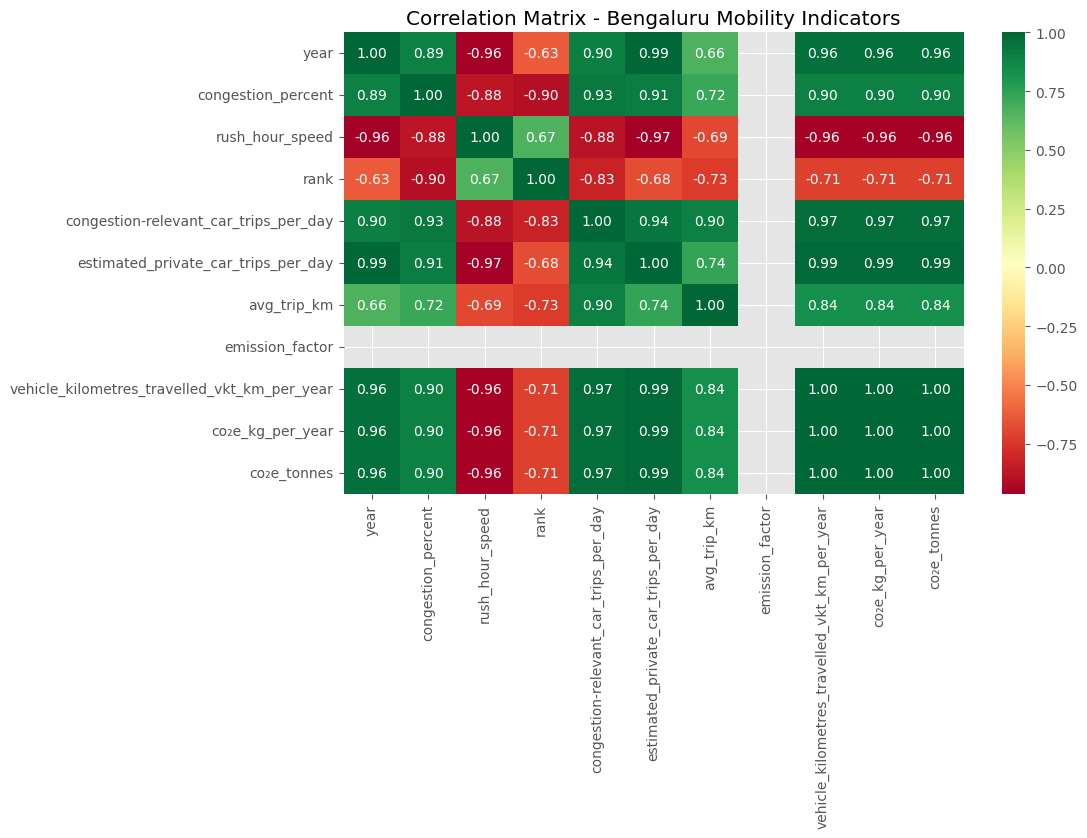

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Correlation Matrix - Bengaluru Mobility Indicators")
plt.show()

In [55]:
!pip install statsmodels


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import statsmodels
print("Installed successfully")

Installed successfully


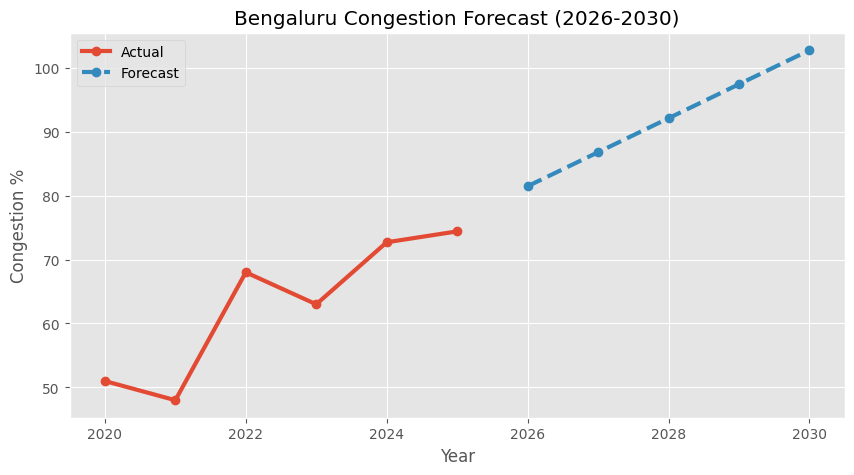

2026     81.460000
2027     86.777143
2028     92.094286
2029     97.411429
2030    102.728572
dtype: float64

In [57]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd


ts = df.set_index("year")["congestion_percent"]


model = ExponentialSmoothing(ts, trend="add", seasonal=None)
fit = model.fit()


forecast = fit.forecast(5)


forecast.index = [2026, 2027, 2028, 2029, 2030]


plt.figure(figsize=(10,5))
plt.plot(ts.index, ts.values, marker="o", linewidth=3, label="Actual")
plt.plot(forecast.index, forecast.values, marker="o", linewidth=3, linestyle="--", label="Forecast")

plt.title("Bengaluru Congestion Forecast (2026-2030)")
plt.xlabel("Year")
plt.ylabel("Congestion %")
plt.legend()
plt.grid(True)
plt.show()

forecast

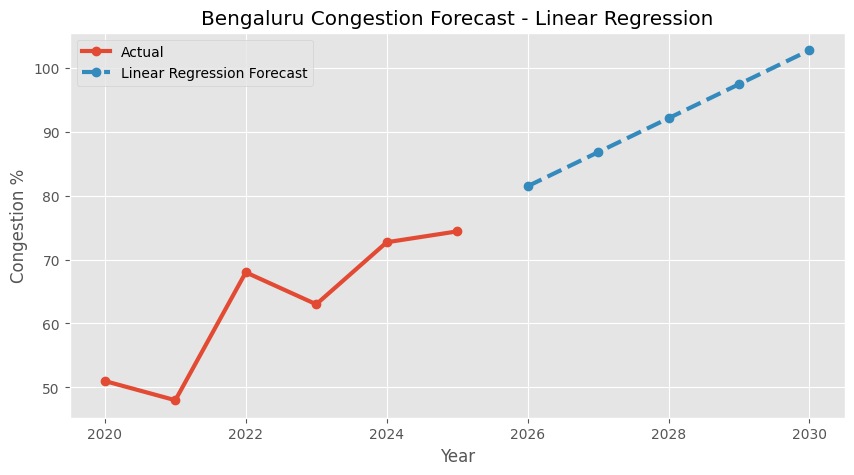

   year  forecast_congestion_percent
0  2026                    81.460000
1  2027                    86.777143
2  2028                    92.094286
3  2029                    97.411429
4  2030                   102.728571


In [58]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd


X = df[["year"]]
y = df["congestion_percent"]


lr = LinearRegression()
lr.fit(X, y)


future_years = pd.DataFrame({"year":[2026,2027,2028,2029,2030]})


pred = lr.predict(future_years)


plt.figure(figsize=(10,5))
plt.plot(df["year"], y, marker="o", linewidth=3, label="Actual")
plt.plot(future_years["year"], pred, marker="o", linestyle="--", linewidth=3, label="Linear Regression Forecast")

plt.title("Bengaluru Congestion Forecast - Linear Regression")
plt.xlabel("Year")
plt.ylabel("Congestion %")
plt.legend()
plt.grid(True)
plt.show()

print(pd.DataFrame({
    "year": future_years["year"],
    "forecast_congestion_percent": pred
}))

In [59]:
trip_change = (df["congestion-relevant_car_trips_per_day"].iloc[-1] - df["congestion-relevant_car_trips_per_day"].iloc[0]) / df["congestion-relevant_car_trips_per_day"].iloc[0]

cong_change = (df["congestion_percent"].iloc[-1] - df["congestion_percent"].iloc[0]) / df["congestion_percent"].iloc[0]

elasticity = cong_change / trip_change

print("Elasticity:", round(elasticity,2))

Elasticity: 0.76


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   city                                          6 non-null      str    
 1   year                                          6 non-null      int64  
 2   congestion_percent                            6 non-null      float64
 3   10_km_time                                    6 non-null      str    
 4   rush_hour_speed                               6 non-null      float64
 5   rank                                          6 non-null      int64  
 6   congestion-relevant_car_trips_per_day         6 non-null      int64  
 7   estimated_private_car_trips_per_day           6 non-null      int64  
 8   avg_trip_km                                   6 non-null      float64
 9   emission_factor                               6 non-null      float64
 10  vehic

In [61]:
import pandas as pd
import numpy as np


elasticity = 0.76


trip_reduction = [5, 10, 15, 20, 25, 30]


scenario_df = pd.DataFrame({
    "trip_reduction_percent": trip_reduction
})

scenario_df["estimated_congestion_reduction_percent"] = (
    scenario_df["trip_reduction_percent"] * elasticity
).round(2)

scenario_df["2025_baseline_congestion"] = 74.4

scenario_df["new_congestion_percent"] = (
    scenario_df["2025_baseline_congestion"] -
    scenario_df["estimated_congestion_reduction_percent"]
).round(2)

scenario_df

,trip_reduction_percent,estimated_congestion_reduction_percent,2025_baseline_congestion,new_congestion_percent
0,5,3.8,74.4,70.6
1,10,7.6,74.4,66.8
2,15,11.4,74.4,63.0
3,20,15.2,74.4,59.2
4,25,19.0,74.4,55.4
5,30,22.8,74.4,51.6


In [62]:
baseline_co2 = 5733420   # 2025 tonnes

scenario_df["co2_saved_tonnes"] = (
    baseline_co2 * scenario_df["trip_reduction_percent"] / 100
).round(0)

scenario_df["new_co2_tonnes"] = (
    baseline_co2 - scenario_df["co2_saved_tonnes"]
).round(0)

scenario_df

,trip_reduction_percent,estimated_congestion_reduction_percent,2025_baseline_congestion,new_congestion_percent,co2_saved_tonnes,new_co2_tonnes
0,5,3.8,74.4,70.6,286671.0,5446749.0
1,10,7.6,74.4,66.8,573342.0,5160078.0
2,15,11.4,74.4,63.0,860013.0,4873407.0
3,20,15.2,74.4,59.2,1146684.0,4586736.0
4,25,19.0,74.4,55.4,1433355.0,4300065.0
5,30,22.8,74.4,51.6,1720026.0,4013394.0


In [63]:
forecast.to_csv("outputs/congestion_forecast.csv", header=["forecast_congestion_percent"])

scenario_df.to_csv("outputs/scenario_analysis.csv", index=False)

print("Files exported successfully.")

Files exported successfully.


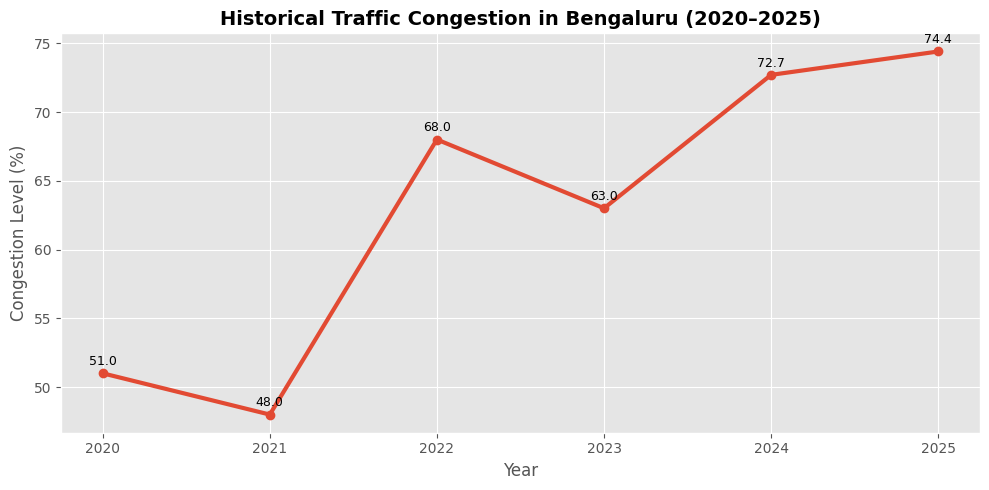

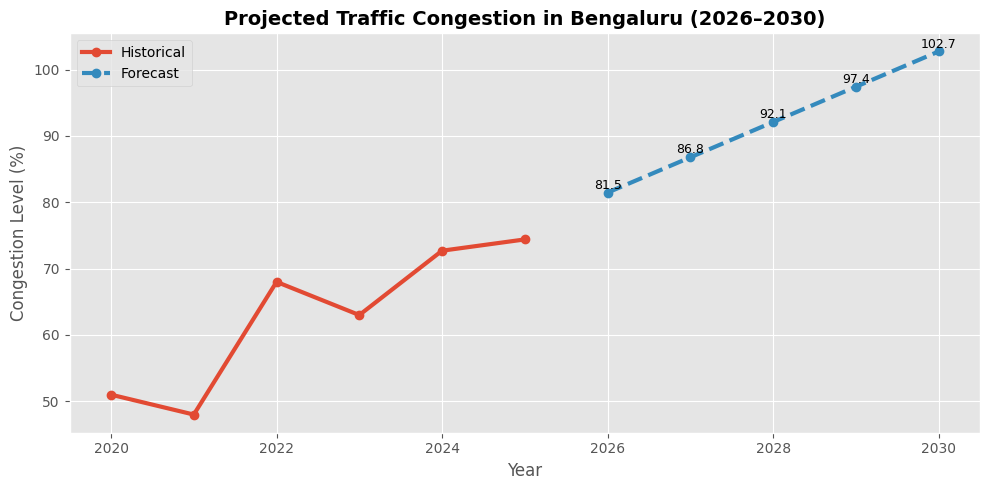

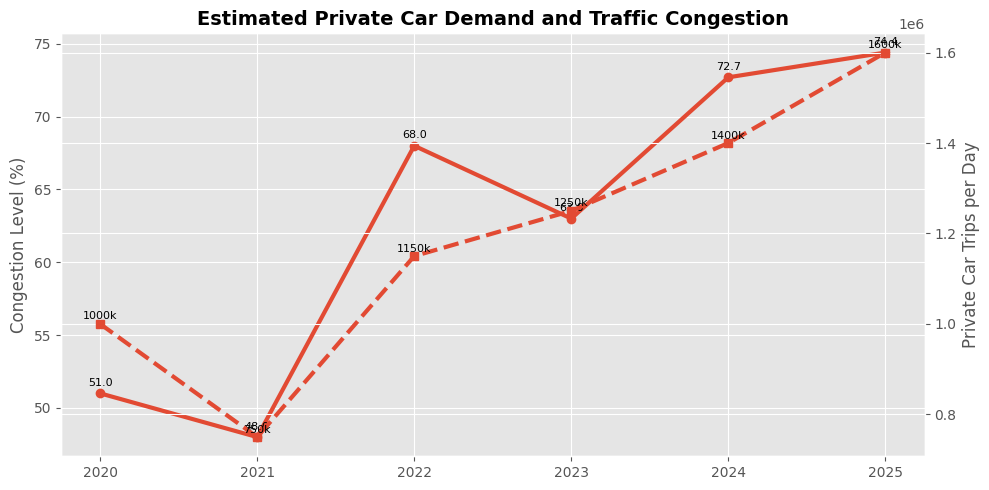

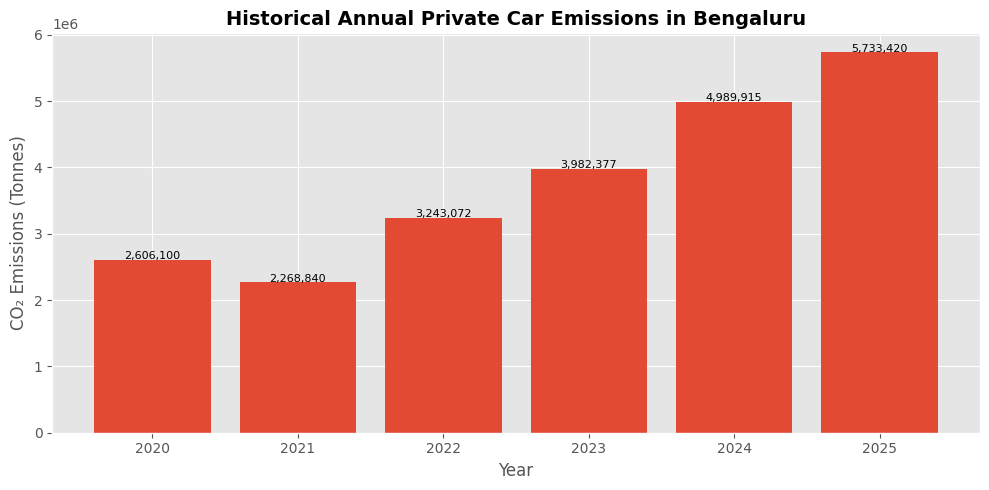

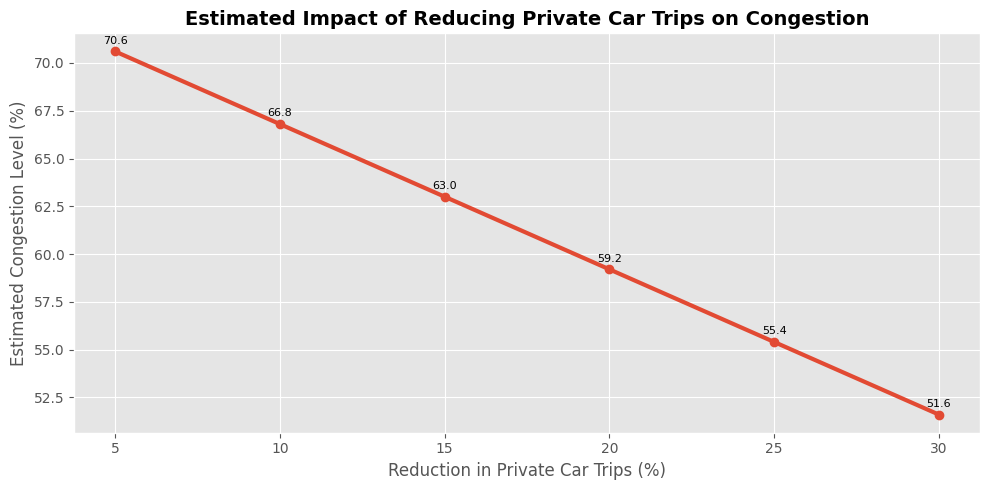

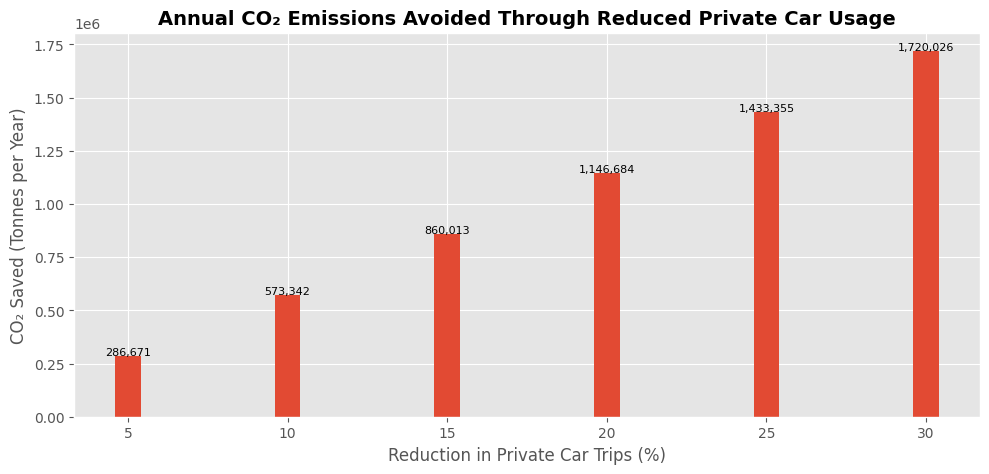

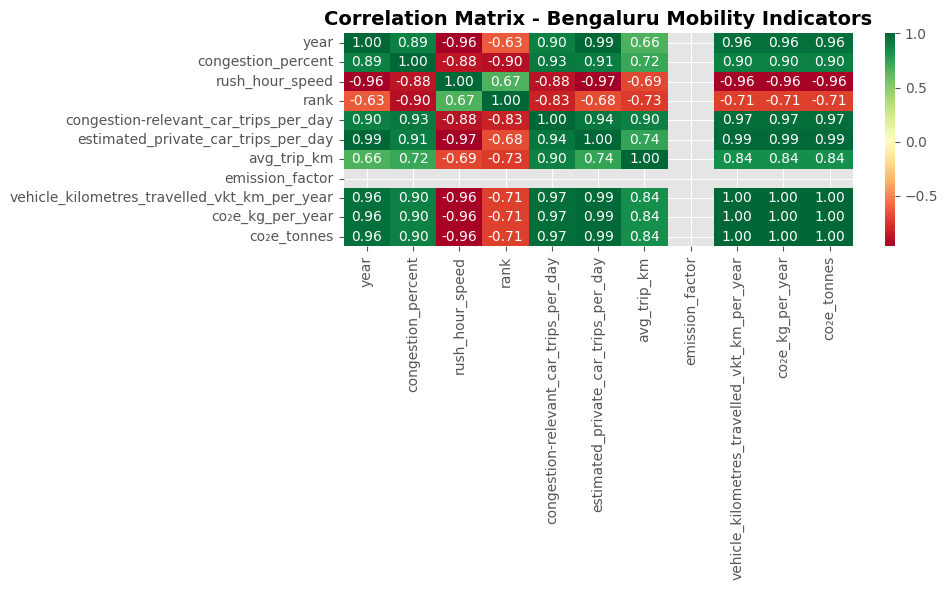

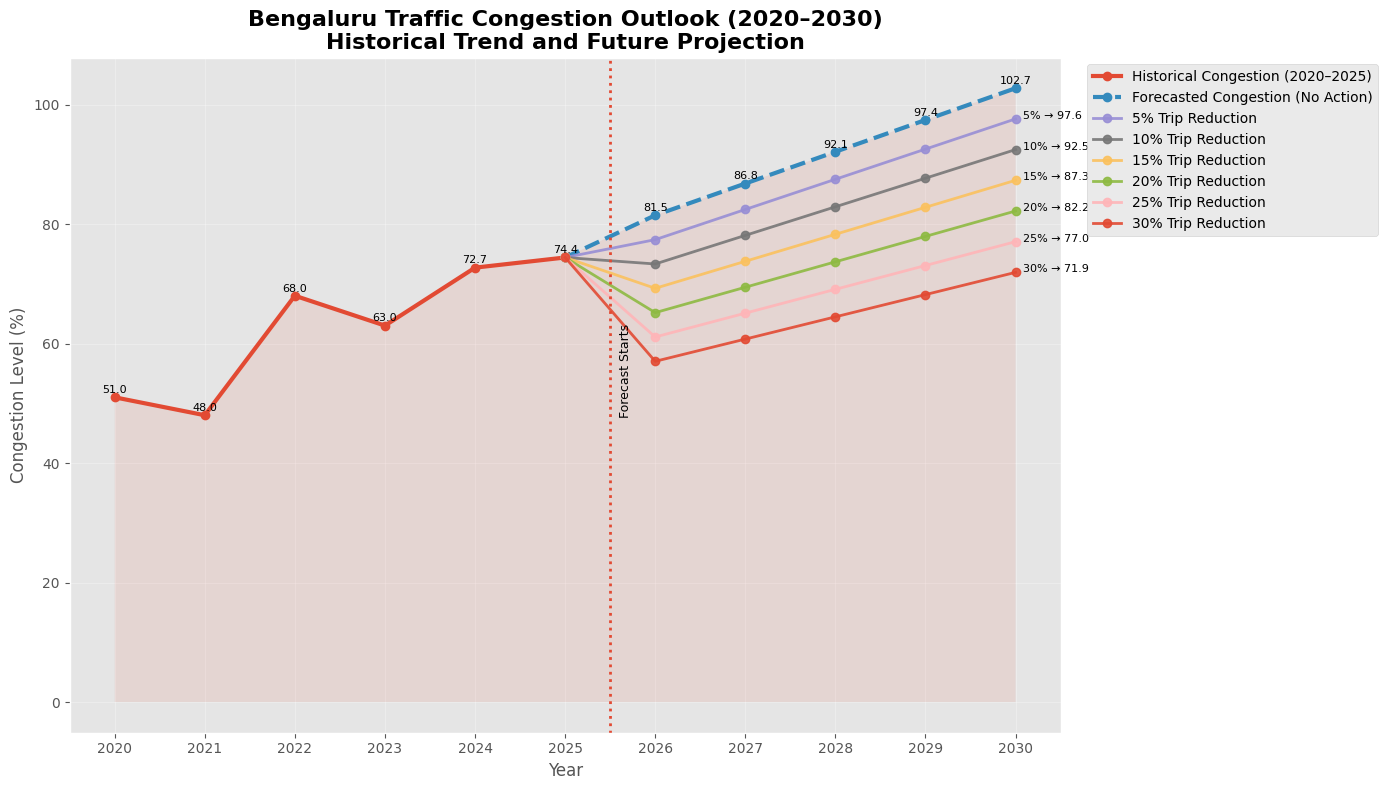

In [65]:
# BENGALURU MOBILITY ANALYSIS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


# 1. Historical Congestion Trend

plt.figure(figsize=(10,5))

plt.plot(df["year"], df["congestion_percent"], marker="o", linewidth=3)

for x, y in zip(df["year"], df["congestion_percent"]):
    plt.text(x, y+0.6, f"{y:.1f}", ha="center", fontsize=9)

plt.title("Historical Traffic Congestion in Bengaluru (2020–2025)", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Congestion Level (%)")
plt.tight_layout()
plt.savefig("outputs/charts/Historical Congestion Trend.png", dpi=300, bbox_inches="tight")
plt.show()



# 2. Forecasted Congestion
# forecast variable already created

plt.figure(figsize=(10,5))

plt.plot(df["year"], df["congestion_percent"], marker="o", linewidth=3, label="Historical")
plt.plot(forecast.index, forecast.values, marker="o", linestyle="--", linewidth=3, label="Forecast")

for x, y in zip(forecast.index, forecast.values):
    plt.text(x, y+0.6, f"{y:.1f}", ha="center", fontsize=9)

plt.title("Projected Traffic Congestion in Bengaluru (2026–2030)", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Congestion Level (%)")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/Forecasted Congestion.png", dpi=300, bbox_inches="tight")
plt.show()



# 3. Car Trips vs Congestion

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(df["year"], df["congestion_percent"], marker="o", linewidth=3, label="Congestion %")
ax1.set_ylabel("Congestion Level (%)")

for x, y in zip(df["year"], df["congestion_percent"]):
    ax1.text(x, y+0.5, f"{y:.1f}", ha="center", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(df["year"], df["congestion-relevant_car_trips_per_day"], marker="s", linewidth=3, linestyle="--", label="Trips")
ax2.set_ylabel("Private Car Trips per Day")

for x, y in zip(df["year"], df["congestion-relevant_car_trips_per_day"]):
    ax2.text(x, y+10000, f"{int(y/1000)}k", ha="center", fontsize=8)

plt.title("Estimated Private Car Demand and Traffic Congestion", fontsize=14, weight="bold")
fig.tight_layout()
plt.savefig("outputs/charts/Car Trips vs Congestion.png", dpi=300, bbox_inches="tight")
plt.show()



# 4. CO2 Trend

plt.figure(figsize=(10,5))

plt.bar(df["year"], df["co₂e_tonnes"])

for x, y in zip(df["year"], df["co₂e_tonnes"]):
    plt.text(x, y+5000, f"{y:,.0f}", ha="center", fontsize=8)

plt.title("Historical Annual Private Car Emissions in Bengaluru", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Tonnes)")
plt.tight_layout()
plt.savefig("outputs/charts/CO2 Trend.png", dpi=300, bbox_inches="tight")
plt.show()


# 5. Scenario Congestion Reduction
# scenario_df already created

plt.figure(figsize=(10,5))

plt.plot(
    scenario_df["trip_reduction_percent"],
    scenario_df["new_congestion_percent"],
    marker="o",
    linewidth=3
)

for x, y in zip(scenario_df["trip_reduction_percent"], scenario_df["new_congestion_percent"]):
    plt.text(x, y+0.4, f"{y:.1f}", ha="center", fontsize=8)

plt.title("Estimated Impact of Reducing Private Car Trips on Congestion", fontsize=14, weight="bold")
plt.xlabel("Reduction in Private Car Trips (%)")
plt.ylabel("Estimated Congestion Level (%)")
plt.tight_layout()
plt.savefig("outputs/charts/Scenario Congestion Reduction.png", dpi=300, bbox_inches="tight")
plt.show()


# 6. CO2 Savings Scenario

plt.figure(figsize=(10,5))

bars = plt.bar(
    scenario_df["trip_reduction_percent"],
    scenario_df["co2_saved_tonnes"]
)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 3000,
        f"{y:,.0f}",
        ha="center",
        fontsize=8
    )

plt.title("Annual CO₂ Emissions Avoided Through Reduced Private Car Usage", fontsize=14, weight="bold")
plt.xlabel("Reduction in Private Car Trips (%)")
plt.ylabel("CO₂ Saved (Tonnes per Year)")
plt.tight_layout()
plt.savefig("outputs/charts/CO2 Savings Scenario.png", dpi=300, bbox_inches="tight")
plt.show()



# 7. Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("Correlation Matrix - Bengaluru Mobility Indicators", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig("outputs/charts/Correlation Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()



# 8. Bengaluru Traffic Congestion Outlook (2020–2030)
# Historical + Forecast + Reduction Scenarios

plt.figure(figsize=(14,8))


# Historical Actuals

plt.plot(
    df["year"],
    df["congestion_percent"],
    marker="o",
    linewidth=3,
    label="Historical Congestion (2020–2025)"
)


# Baseline Forecast STARTS FROM 2025

x_base = [2025] + list(forecast.index)
y_base = [74.4] + list(forecast.values)

plt.plot(
    x_base,
    y_base,
    marker="o",
    linestyle="--",
    linewidth=3,
    label="Forecasted Congestion (No Action)"
)


# Reduction Scenario Lines

reductions = [5,10,15,20,25,30]

for r in reductions:

    x_vals = [2025] + list(forecast.index)
    y_vals = [74.4] + list(forecast.values * (1-r/100))

    plt.plot(
        x_vals,
        y_vals,
        marker="o",
        linewidth=2,
        alpha=0.9,
        label=f"{r}% Trip Reduction"
    )


# Fill Area Under Baseline

all_years = list(df["year"]) + list(forecast.index)
all_values = list(df["congestion_percent"]) + list(forecast.values)

plt.fill_between(
    all_years,
    all_values,
    alpha=0.10
)


# Historical Labels

for x, y in zip(df["year"], df["congestion_percent"]):
    plt.text(x, y+0.7, f"{y:.1f}", ha="center", fontsize=8)


# Baseline Forecast Labels

for x, y in zip(forecast.index, forecast.values):
    plt.text(x, y+0.7, f"{y:.1f}", ha="center", fontsize=8)


# Scenario Labels at 2030

for r in reductions:

    y = forecast.values[-1] * (1-r/100)

    plt.text(
        2030.08,
        y,
        f"{r}% → {y:.1f}",
        fontsize=8
    )


# Forecast Divider

plt.axvline(
    x=2025.5,
    linestyle=":",
    linewidth=2
)

plt.text(
    2025.6,
    48,
    "Forecast Starts",
    rotation=90,
    fontsize=9
)



plt.title(
    "Bengaluru Traffic Congestion Outlook (2020–2030)\nHistorical Trend and Future Projection",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Congestion Level (%)")
plt.xticks(range(2020,2031))
plt.grid(True, alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("outputs/charts/Bengaluru Traffic Congestion Outlook (2020–2030).png", dpi=300, bbox_inches="tight")
plt.show()